In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("insurance_pre.csv")

In [3]:
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [4]:
dataset = pd.get_dummies(dataset).astype(int)

In [5]:
dataset

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19,27,0,16884,1,0,0,1
1,18,33,1,1725,0,1,1,0
2,28,33,3,4449,0,1,1,0
3,33,22,0,21984,0,1,1,0
4,32,28,0,3866,0,1,1,0
...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,0,1,1,0
1334,18,31,0,2205,1,0,1,0
1335,18,36,0,1629,1,0,1,0
1336,21,25,0,2007,1,0,1,0


In [6]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes'],
      dtype='object')

In [7]:
independent = dataset[['age', 'bmi', 'children', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes']]

In [8]:
independent

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes
0,19,27,0,1,0,0,1
1,18,33,1,0,1,1,0
2,28,33,3,0,1,1,0
3,33,22,0,0,1,1,0
4,32,28,0,0,1,1,0
...,...,...,...,...,...,...,...
1333,50,30,3,0,1,1,0
1334,18,31,0,1,0,1,0
1335,18,36,0,1,0,1,0
1336,21,25,0,1,0,1,0


In [9]:
dependent = dataset[['charges']]

In [10]:
dependent

,charges
0,16884
1,1725
2,4449
3,21984
4,3866
...,...
1333,10600
1334,2205
1335,1629
1336,2007


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(independent, dependent,test_size=0.30,random_state=0)

In [43]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='squared_error', max_features=None, splitter='random')
regressor.fit(X_train,Y_train)

,criterion,'squared_error'
,splitter,'random'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


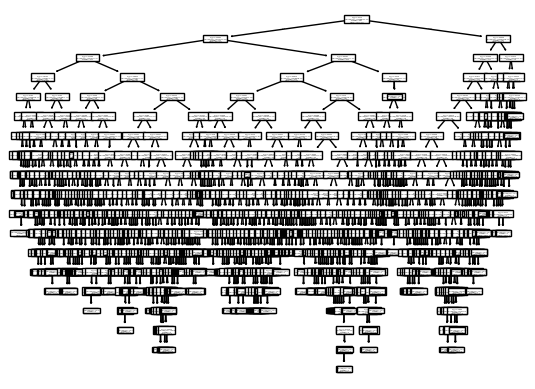

In [44]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [45]:
y_pred=regressor.predict(X_test)

In [46]:
from sklearn.metrics import r2_score
r2_score=r2_score(Y_test,y_pred)
r2_score

0.6265226003943725

In [48]:
r2_score

0.6265226003943725